# Top

In [1]:
%matplotlib inline
%load_ext autoreload
from verimon.analysis import *

experiment_dir = "../stats/exp-2025-01-21_11-44-52-compare-trad-premise-snl"
experiment_data = load_experiment_data(experiment_dir)

symbols, colors = add_symbol_color(experiment_data)

clean_data(experiment_data)

add_short_names(experiment_data)

experiments_in_legends = False
save_figures = True
save_path = "../VerifiableMonitorsTex/inprogress/images/plots"
verimon_data = [d for d in experiment_data if "verimon" in d]

Loaded 108 JSON files from ../stats/exp-2025-01-21_11-44-52-compare-trad-premise-snl


In [2]:
import os

os.system(f"grep -r 'WARNING' {experiment_dir}/logs/*")
os.system(f"grep -r 'ERROR' {experiment_dir}/logs/*")
longest_experiment = max(experiment_data, key=lambda x: x["time"]["total"])
print(
    f"Longest experiment {longest_experiment['experiment']['name']} {longest_experiment['experiment']['variant']} took {longest_experiment['time']['total']:.2f}s ({longest_experiment['time']['total'] / 60:.2f} min ({longest_experiment['time']['total'] / (60 * 60):.2f} h))."
)

Longest experiment compare-trad (file=airportB-7.nm,old_walks_per_state=100,threshold=0.055) took 19008.58s (316.81 min (5.28 h)).


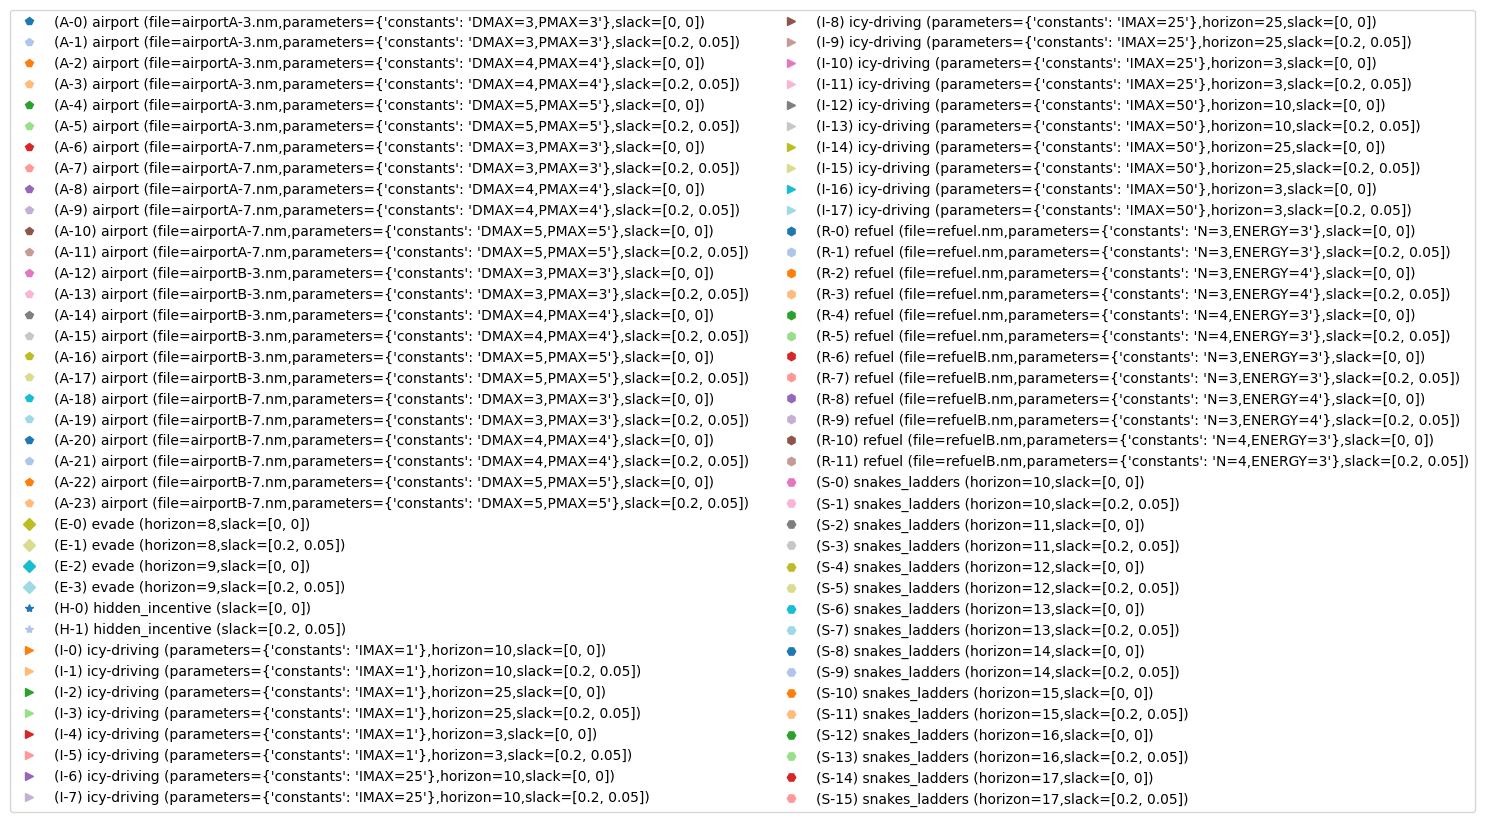

In [3]:
import matplotlib.backend_bases
from matplotlib.backends.backend_pgf import FigureCanvasPgf

matplotlib.backend_bases.register_backend("pdf", FigureCanvasPgf)

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

# Create a legend for the symbols and colors
legend_elements = [
    mlines.Line2D(
        [],
        [],
        linewidth=0,
        color=data["color"],
        marker=data["symbol"],
        label=f'({data["experiment"]["short_name"]}) {data["experiment"]["name"]} {data["experiment"]["variant"]}',
    )
    for data in verimon_data
]

plt.legend(handles=legend_elements, loc="center", ncol=2)
plt.axis("off")
if save_figures:
    plt.savefig(f"{save_path}/legend.pgf", bbox_inches="tight")
plt.show()

# generate_experiment_table(verimon_data, False, save_path, "experiments")

# Compare runtimes of verimon and traditional learning

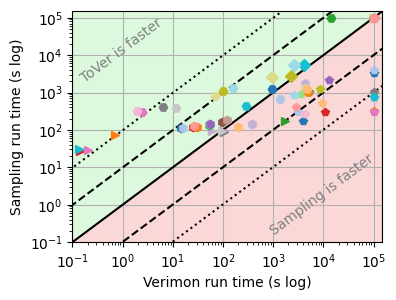

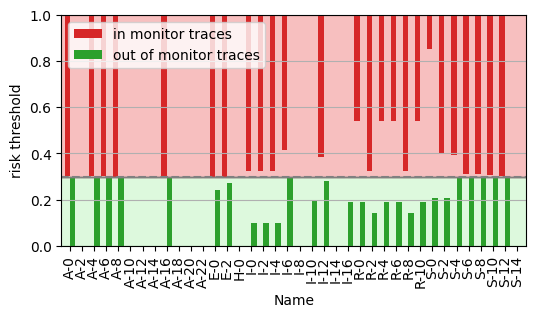

/home/luko/Documents/MDP-product/verimon/analysis.py:660: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


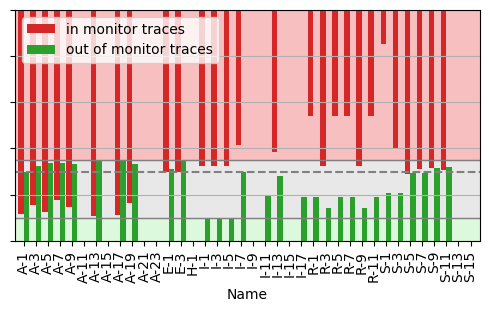

/home/luko/Documents/MDP-product/verimon/analysis.py:660: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


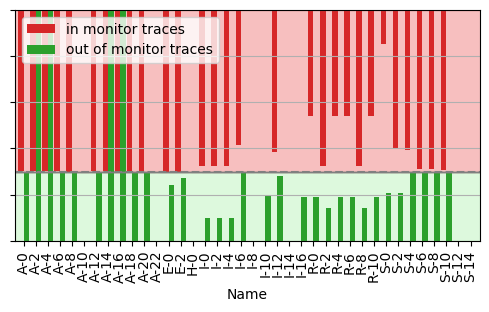

In [4]:
compare_runtimes(
    verimon_data,
    "verimon",
    "sampling",
    title="Comparison of ToVer vs Sampling learning runtime",
    figsize=(4, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
)
# compare_thresholds(verimon_data, "verimon", "sampling", colors)
compare_thresholds_bar(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0],
    ["verimon"],
    "name",
    lambda d: f"{d['experiment']['short_name']}",
    colors,
    0.3,
    fig_size=(6, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="thresholds_tover_no_slack",
)
compare_thresholds_bar(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0.2],
    ["verimon"],
    "name",
    lambda d: f"{d['experiment']['short_name']}",
    colors,
    0.3,
    0.05,
    0.2,
    fig_size=(6, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="thresholds_tover_slack",
    show_y_axis=False,
)

compare_thresholds_bar(
    verimon_data,
    ["sampling"],
    "name",
    lambda d: f"{d['experiment']['short_name']}",
    colors,
    0.3,
    bundle=2,
    fig_size=(6, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="theresholds_sampling",
    show_y_axis=False,
)

# Compare learned monitor sizes

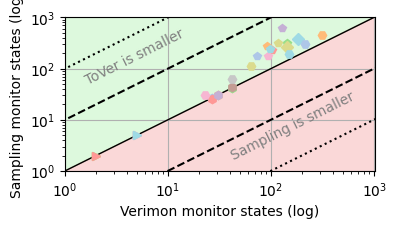

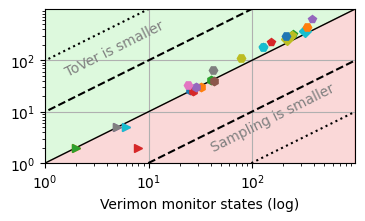

In [5]:
compare_monitor_sizes(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0.2],
    "verimon",
    "sampling",
    figsize=(4, 2),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="monitor_sizes_with_slack",
)
compare_monitor_sizes(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0],
    "verimon",
    "sampling",
    figsize=(4, 2),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="monitor_sizes_no_slack",
    show_y_axis=False,
)

# Runtime by parameters

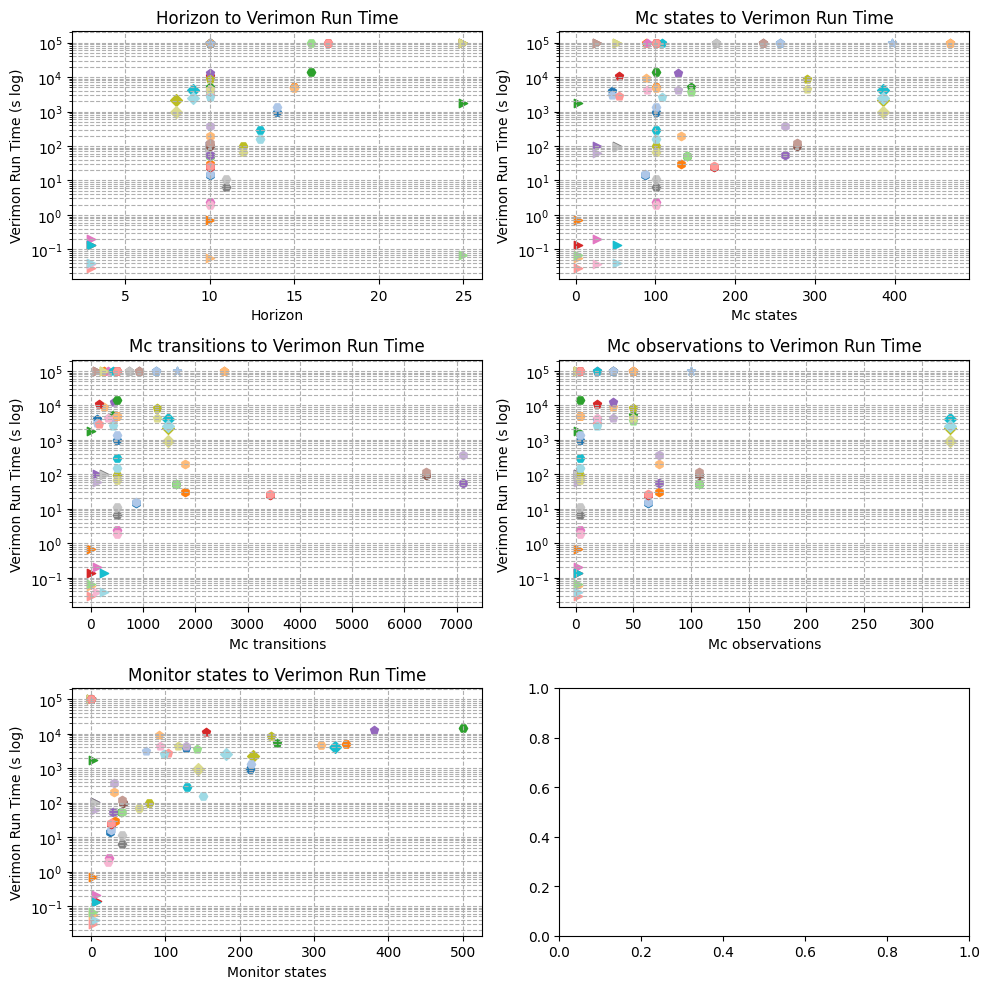

In [6]:
parameters = [
    ("experiment", "horizon", "log"),
    ("mc", "mc_states", "log"),
    ("mc", "mc_transitions", "log"),
    ("mc", "mc_observations", "log"),
    ("verimon", "monitor_states", "log"),
]

runtime_by_params(
    [data for data in experiment_data if "verimon" in data],
    "verimon",
    parameters,
    experiments_in_legends=experiments_in_legends,
)

# Compare horizon on and off in snakes and ladders data

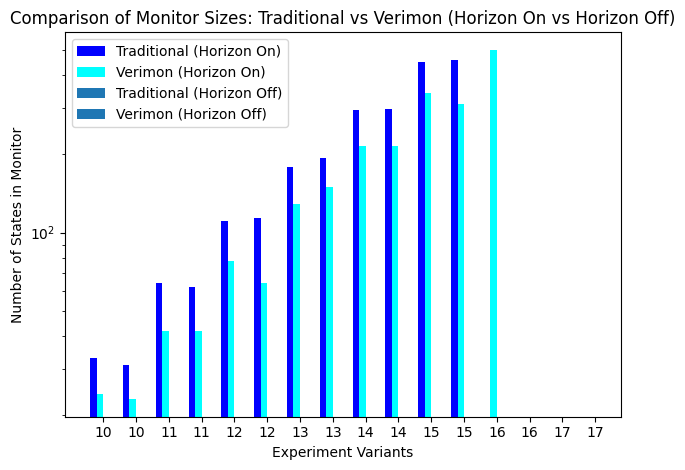

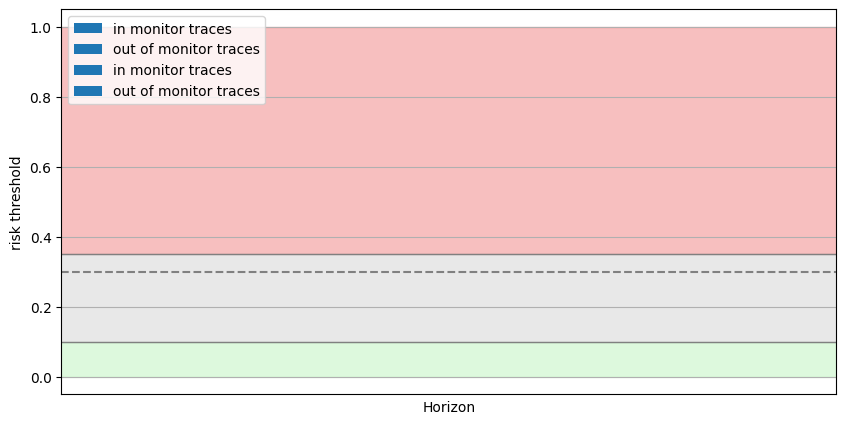

In [7]:
# Filter data for snakes and ladders experiments
snakes_ladders_data = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "snakes_ladders"
    ],
    key=lambda x: x["experiment"]["horizon"],
)

# Separate data based on use_horizon_in_filtering
horizon_on_data = [
    data
    for data in snakes_ladders_data
    if data["experiment"]["use_horizon_in_filtering"]
]
horizon_off_data = [
    data
    for data in snakes_ladders_data
    if not data["experiment"]["use_horizon_in_filtering"]
]

# Extract monitor sizes
horizon_on_trad_sizes = [data["sampling"]["monitor_states"] for data in horizon_on_data]
horizon_on_verimon_sizes = [
    data["verimon"]["monitor_states"] for data in horizon_on_data
]
horizon_off_trad_sizes = [
    data["sampling"]["monitor_states"] for data in horizon_off_data
]
horizon_off_verimon_sizes = [
    data["verimon"]["monitor_states"] for data in horizon_off_data
]

# Horizon sizes for x-axis labels
horizon_on_names = [data["experiment"]["horizon"] for data in horizon_on_data]
horizon_off_names = [data["experiment"]["horizon"] for data in horizon_off_data]

bar_width = 1 / 4 - 0.05
index_on = range(len(horizon_on_data))
index_off = range(len(horizon_off_data))

# Plot for use_horizon_in_filtering = True
plt.bar(
    index_on,
    horizon_on_trad_sizes,
    bar_width,
    label="Traditional (Horizon On)",
    color="blue",
)
plt.bar(
    [i + bar_width for i in index_on],
    horizon_on_verimon_sizes,
    bar_width,
    label="Verimon (Horizon On)",
    color="cyan",
)

# Plot for use_horizon_in_filtering = False
plt.bar(
    [i + 2 * bar_width for i in index_off],
    horizon_off_trad_sizes,
    bar_width,
    label="Traditional (Horizon Off)",
    color="red",
)
plt.bar(
    [i + 3 * bar_width for i in index_off],
    horizon_off_verimon_sizes,
    bar_width,
    label="Verimon (Horizon Off)",
    color="orange",
)

plt.xlabel("Experiment Variants")
plt.ylabel("Number of States in Monitor")
plt.title(
    "Comparison of Monitor Sizes: Traditional vs Verimon (Horizon On vs Horizon Off)"
)
plt.xticks(
    [i + bar_width * 3 / 2 for i in index_on],
    horizon_on_names,
)
plt.legend()
plt.yscale("log")

plt.tight_layout()
plt.show()

# Plot for use_horizon_in_filtering = True
# Interleave horizon on and off data
interleaved_data = []
for on, off in zip(horizon_on_data, horizon_off_data):
    interleaved_data.append(on)
    interleaved_data.append(off)

compare_thresholds_bar(
    interleaved_data,
    ["verimon", "sampling"],
    "horizon",
    lambda d: f"{d['experiment']['horizon']} - {'use' if d['experiment']['use_horizon_in_filtering'] else 'not use'}",
    colors,
    0.3,
    0.05,
    0.2,
)

# Compare thresholds and amount of samples

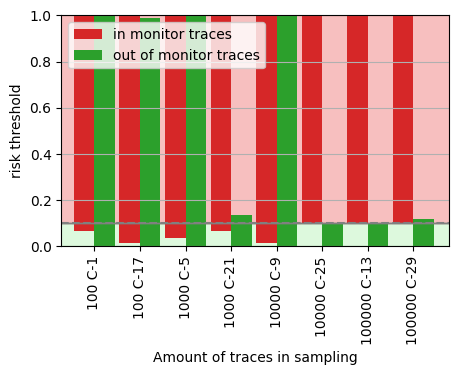

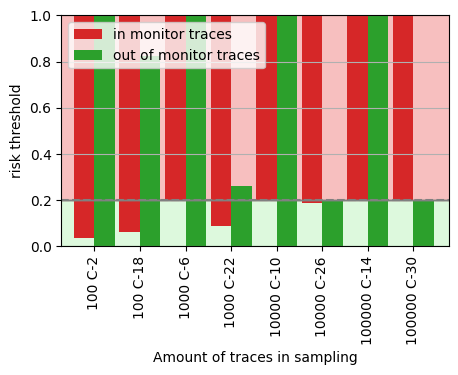

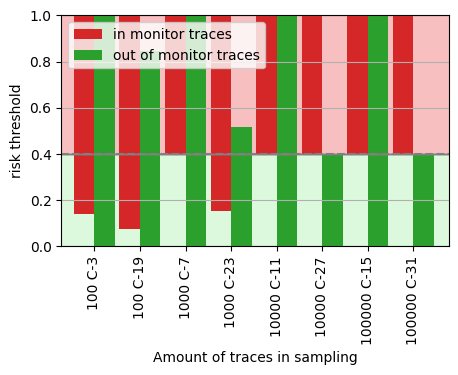

In [ ]:
compare_trad_data_low_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.1
            or data["experiment"]["threshold"] == Fraction(1, 10)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)
compare_trad_data_mid_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.2
            or data["experiment"]["threshold"] == Fraction(1, 5)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)
compare_trad_data_high_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.4
            or data["experiment"]["threshold"] == Fraction(2, 5)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)

compare_thresholds_bar(
    compare_trad_data_low_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    colors,
    threshold=0.1,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_low",
)
compare_thresholds_bar(
    compare_trad_data_mid_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    colors,
    threshold=0.2,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_mid",
    show_y_axis=False,
)
compare_thresholds_bar(
    compare_trad_data_high_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    colors,
    threshold=0.4,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_high",
    show_y_axis=False,
)

# Relative time spent in paynt, product generator and other

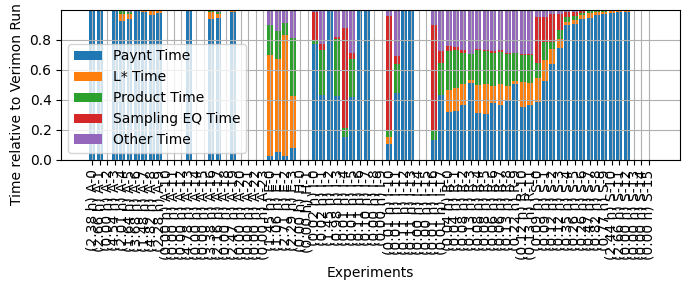

In [9]:
import numpy as np


filtered_data = [
    data for data in experiment_data if data["experiment"]["name"] != "compare-trad"
]
product_times = [
    (
        data["verimon"]["product_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
paynt_times = [
    (
        data["verimon"]["paynt_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
eq_times = [
    (
        data["verimon"]["eq_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
lstar_times = [
    (
        data["verimon"]["lstar_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
other_times = [
    (
        1
        - (
            data["verimon"]["product_time"]
            + data["verimon"]["paynt_time"]
            + data["verimon"]["eq_time"]
            + data["verimon"]["lstar_time"]
        )
        / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]

if experiments_in_legends:
    experiment_names = [
        f"{data['experiment']['name']}\n{data['experiment']['variant']}\n({data['time']['total']/(60*60):.2f} h)"
        for data in filtered_data
    ]
else:
    experiment_names = [
        f"({data['time']['total']/(60*60):.2f} h) {data['experiment']['short_name']}"
        for data in filtered_data
    ]

plt.figure(figsize=(7, 3))
index = range(len(filtered_data))
bottom = np.zeros(len(filtered_data))


plt.bar(index, paynt_times, label="Paynt Time")
bottom += paynt_times
plt.bar(index, lstar_times, bottom=bottom, label="L* Time")
bottom += lstar_times
plt.bar(index, product_times, bottom=bottom, label="Product Time")
bottom += product_times
plt.bar(
    index,
    eq_times,
    bottom=bottom,
    label="Sampling EQ Time",
)
bottom += eq_times
plt.bar(
    index,
    other_times,
    bottom=bottom,
    label="Other Time",
)

plt.xlabel("Experiments")
plt.ylabel("Time relative to Verimon Run Time")
plt.xticks(index, experiment_names, rotation=90)
plt.legend()

plt.tight_layout()
plt.grid()
if save_figures:
    plt.savefig(f"{save_path}/verimon_times.pgf", bbox_inches="tight")
plt.show()

In [10]:
from verimon.analysis import runtime_from_logs

for data in experiment_data:
    if "verimon" in data:
        print("\n", data["experiment"]["name"], data["experiment"]["variant"])
        print(data["log_path"])
        times = runtime_from_logs(data["log_path"])
        print(
            "\n".join(
                map(str, sorted(times.items(), key=lambda x: x[1], reverse=True)[:5])
            )
        )


 airport (file=airportA-3.nm,parameters={'constants': 'DMAX=3,PMAX=3'},slack=[0, 0])
../stats/exp-2025-01-21_11-44-52-compare-trad-premise-snl/logs/2025-01-21_11-44-52_airport_(file=airportA-3.nm,parameters={'constants': 'DMAX=3,PMAX=3'},slack=[0, 0]).log
('generator.py:189 - no counterexamples above threshold', 2739.8199999999997)
('generator.py:179 - counterexample found: A(2,0)={d:1,pobs:2,turn:0}, A(3,0)={d:1,pobs:1,turn:1}, A(4,0)={d:1,pobs:1,turn:0}, A(5,0)={d:1,pobs:0,turn:0}, A(6,0)={d:1,pobs:1,turn:1}, A(7,0)={d:0,pobs:0,turn:1}, A(8,0)={d:0,pobs:1,turn:0}, A(9,0)=end, A(10,0)={d:1,pobs:2,turn:1}, A(11,0)={d:0,pobs:1,turn:1}, A(12,0)={d:2,pobs:2,turn:0}, A(13,0)={d:0,pobs:1,turn:0}, A(14,0)={d:1,pobs:2,turn:1}, A(15,0)={d:0,pobs:2,turn:1}, A(16,0)={d:2,pobs:2,turn:0}, A(17,0)={d:0,pobs:2,turn:0}, A(19,0)=end (1349734629199499/1931203119120000)', 1537.53)
('generator.py:179 - counterexample found: A(2,0)={d:1,pobs:2,turn:0}, A(3,0)={d:1,pobs:1,turn:1}, A(4,0)={d:1,pobs:1,turn: